In [2]:
# Import Required Libraries
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

In [25]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: d:\Crop_Disease_Detection


In [3]:
# Define the dataset path
dataset_path = Path("../data/raw/color")

print("Dataset Path:")
print(dataset_path.resolve())

Dataset Path:
D:\Crop_Disease_Detection\data\raw\color


In [4]:
# Check Dataset Exists
if dataset_path.exists():
    print("Dataset found.")
else:
    print("Dataset NOT found.")

Dataset found.


In [5]:
# Count Number of Classes for Each Crop
class_names = sorted(
    [folder.name for folder in dataset_path.iterdir() if folder.is_dir()]
)

print(f"Total Classes: {len(class_names)}")

Total Classes: 38


In [6]:
# Print All Classes Names
for i, class_name in enumerate(class_names, start=1):
    print(f"{i}. {class_name}")

1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spider_mites Two-spotted_spider_

In [7]:
# Count Images in Each class
image_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    
    # Count only image files
    images = [
        img for img in class_path.iterdir()
        if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    
    image_counts[class_name] = len(images)

print("Image counting completed.")

Image counting completed.


In [8]:
# Create a DataFrame for Image Counts
df = pd.DataFrame(
    image_counts.items(),
    columns=["Class", "Number of Images"]
)

df

,Class,Number of Images
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___Powdery_mildew,1052
6,Cherry_(including_sour)___healthy,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___Northern_Leaf_Blight,985


In [9]:
# Dataset Statistics
total_images = df["Number of Images"].sum()

largest_class = df.loc[df["Number of Images"].idxmax()]

smallest_class = df.loc[df["Number of Images"].idxmin()]

average_images = df["Number of Images"].mean()

print(f"Total Images : {total_images}")
print(f"Average Images per Class : {average_images:.2f}")
print()
print("Largest Class")
print(largest_class)
print()
print("Smallest Class")
print(smallest_class)

Total Images : 54305
Average Images per Class : 1429.08

Largest Class
Class               Orange___Haunglongbing_(Citrus_greening)
Number of Images                                        5507
Name: 15, dtype: object

Smallest Class
Class               Potato___healthy
Number of Images                 152
Name: 22, dtype: object


In [10]:
# Sort the Tables
df = df.sort_values(
    by="Number of Images",
    ascending=False
)

df.reset_index(drop=True, inplace=True)

df

,Class,Number of Images
0,Orange___Haunglongbing_(Citrus_greening),5507
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
2,Soybean___healthy,5090
3,Peach___Bacterial_spot,2297
4,Tomato___Bacterial_spot,2127
5,Tomato___Late_blight,1909
6,Squash___Powdery_mildew,1835
7,Tomato___Septoria_leaf_spot,1771
8,Tomato___Spider_mites Two-spotted_spider_mite,1676
9,Apple___healthy,1645


In [11]:
df.to_csv("../outputs/class_distribution.csv", index=False)

print("CSV file saved successfully.")

CSV file saved successfully.


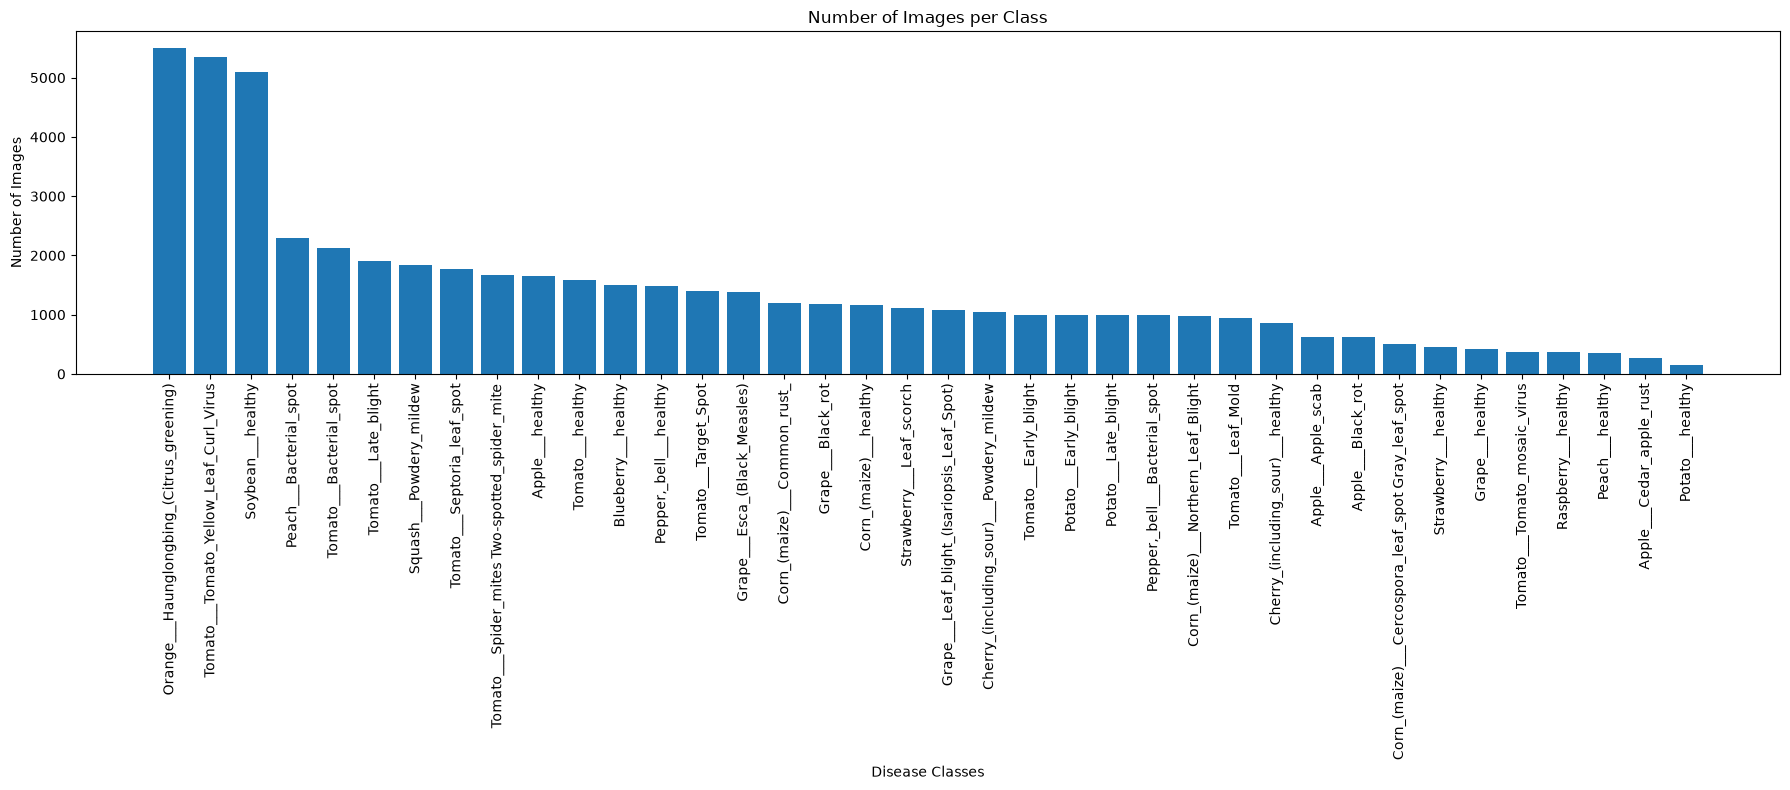

In [12]:
# Plot class Distribution
plt.figure(figsize=(18, 8))

plt.bar(df["Class"], df["Number of Images"])

plt.xticks(rotation=90)

plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

plt.tight_layout()

plt.show()

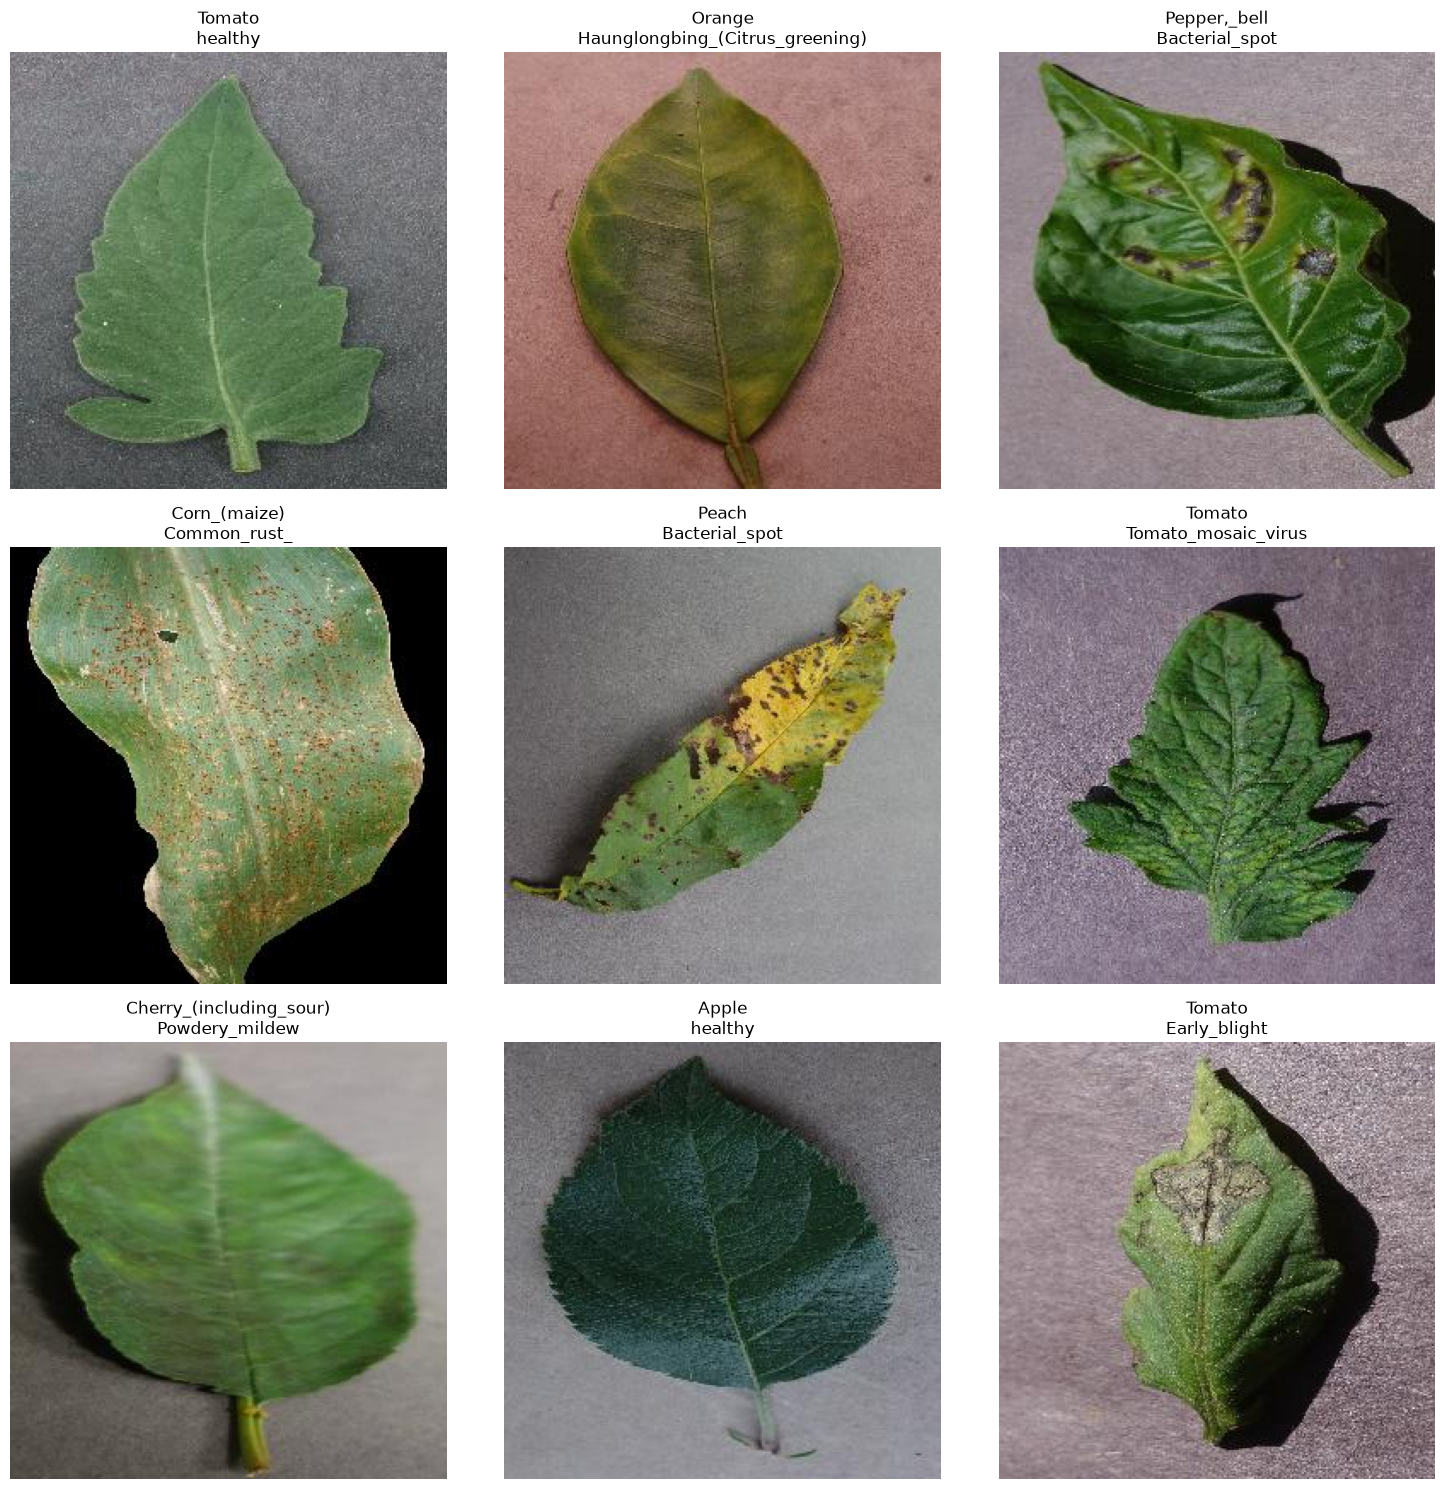

In [15]:
# Display Random Sample Images
import random

# Number of sample classes to display
num_samples = 9

sample_classes = random.sample(class_names, num_samples)

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(sample_classes):
    
    class_path = dataset_path / class_name
    
    image_path = random.choice(list(class_path.glob("*")))
    
    image = Image.open(image_path)
    
    plt.subplot(3, 3, i + 1)
    
    plt.imshow(image)
    plt.title(class_name.replace("___", "\n"))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Analyze Image Sizes
image_sizes = []

for class_name in class_names:
    
    class_path = dataset_path / class_name
    
    for image_file in class_path.glob("*"):
        
        try:
            img = Image.open(image_file)
            image_sizes.append(img.size)
        except:
            pass

print(f"Total Images Checked: {len(image_sizes)}")

Total Images Checked: 54305


In [17]:
sizes_df = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

sizes_df.head()

,Width,Height
0,256,256
1,256,256
2,256,256
3,256,256
4,256,256


In [18]:
sizes_df.describe()

,Width,Height
count,54305.0,54305.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


In [20]:
# Check Unique Image Sizes
unique_sizes = sizes_df.value_counts()

print(f"Unique Image Sizes: {len(unique_sizes)}")

unique_sizes.head(10)

Unique Image Sizes: 1


Width  Height
256    256       54305
Name: count, dtype: int64

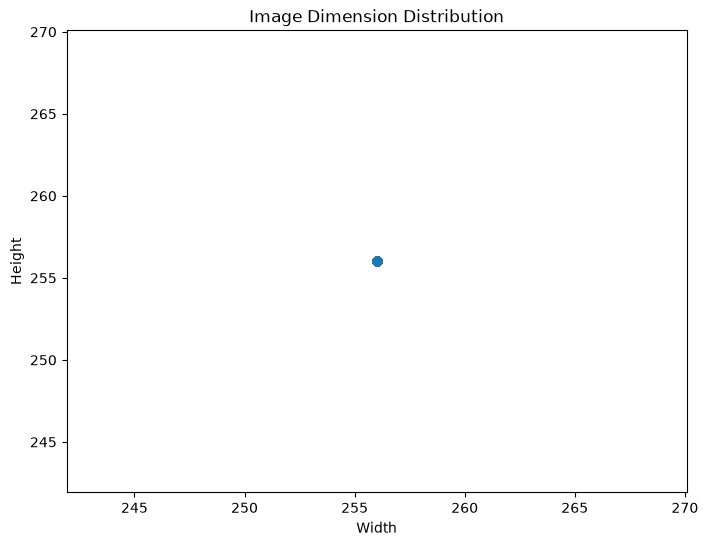

In [21]:
# Visualize Image Size Distribution
plt.figure(figsize=(8,6))

plt.scatter(
    sizes_df["Width"],
    sizes_df["Height"],
    alpha=0.3
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimension Distribution")

plt.show()

In [22]:
# Detect Corrupted Images
corrupted_images = []

for class_name in class_names:
    
    class_path = dataset_path / class_name
    
    for image_file in class_path.glob("*"):
        
        try:
            img = Image.open(image_file)
            img.verify()
        except:
            corrupted_images.append(str(image_file))

print(f"Corrupted Images Found: {len(corrupted_images)}")

Corrupted Images Found: 0


In [23]:
summary = pd.DataFrame({
    "Metric": [
        "Total Classes",
        "Total Images",
        "Average Images per Class",
        "Largest Class Images",
        "Smallest Class Images",
        "Corrupted Images"
    ],
    
    "Value": [
        len(class_names),
        total_images,
        round(average_images,2),
        largest_class["Number of Images"],
        smallest_class["Number of Images"],
        len(corrupted_images)
    ]
})

summary

,Metric,Value
0,Total Classes,38.00
1,Total Images,54305.00
2,Average Images per Class,1429.08
3,Largest Class Images,5507.00
4,Smallest Class Images,152.00
5,Corrupted Images,0.00


In [24]:
summary.to_csv("../outputs/dataset_summary.csv", index=False)

print("Dataset summary saved successfully.")

Dataset summary saved successfully.


In [26]:
from src.preprocessing.data_loader import load_dataset